# Knee Osteoarthritis Classification - Multi-Model Training
## Using VGG16, VGG19, ResNet101, MobileNetV2, InceptionV3, and DenseNet121

## 1. Setup and Imports

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
from tqdm import tqdm
import pandas as pd
import time
import os


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Using device: cuda


## 2. Setup for Kaggle
### Note: Upload your dataset to Kaggle and update the paths below

In [8]:
import os
print("Running on Kaggle")
print(f"Available CPUs: {os.cpu_count()}")
print(f"GPU Available: {torch.cuda.is_available()}")


if os.path.exists('/kaggle/input'):
    print("\nAvailable datasets in /kaggle/input:")
    for item in os.listdir('/kaggle/input'):
        print(f"  - {item}")

Running on Kaggle
Available CPUs: 4
GPU Available: True

Available datasets in /kaggle/input:
  - datasets


## 3. Hyperparameters and Data Paths

In [9]:
BATCH_SIZE = 32
LEARNING_RATE = 0.0001
NUM_EPOCHS = 50
NUM_CLASSES = 5
IMG_SIZE = 224
IMG_SIZE_INCEPTION = 299


import os

BASE_PATH = '/kaggle/input/filters-applied-to-test-train-val'

if os.path.exists(BASE_PATH):
    print(f"Contents of {BASE_PATH}:")
    for item in os.listdir(BASE_PATH):
        print(f"   └── {item}")

    contents = os.listdir(BASE_PATH)
    TRAIN_DIR = None
    VAL_DIR = None
    TEST_DIR = None

    for folder in contents:
        folder_lower = folder.lower()
        folder_path = os.path.join(BASE_PATH, folder)

        if 'train' in folder_lower:
            TRAIN_DIR = folder_path
        elif 'val' in folder_lower:
            VAL_DIR = folder_path
        elif 'test' in folder_lower:
            TEST_DIR = folder_path

    print(f"\nAuto-detected paths:")
else:
    print(f"Base path not found: {BASE_PATH}")
    TRAIN_DIR = '/kaggle/input/datasets/abdelrahman0211/filters-applied-to-test-train-val/filtered_Train_dataset'
    VAL_DIR = '/kaggle/input/datasets/abdelrahman0211/filters-applied-to-test-train-val/Filtered Val'
    TEST_DIR = '/kaggle/input/datasets/abdelrahman0211/filters-applied-to-test-train-val/Filtered test'

print(f"\nBatch Size: {BATCH_SIZE}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE} (was 224, now 256 for more detail)")
print(f"Image Size InceptionV3: {IMG_SIZE_INCEPTION}x{IMG_SIZE_INCEPTION}")
print(f"\nData paths:")
print(f"  Train: {TRAIN_DIR} {'OK' if TRAIN_DIR and os.path.exists(TRAIN_DIR) else 'NOT FOUND'}")
print(f"  Val:   {VAL_DIR} {'OK' if VAL_DIR and os.path.exists(VAL_DIR) else 'NOT FOUND'}")
print(f"  Test:  {TEST_DIR} {'OK' if TEST_DIR and os.path.exists(TEST_DIR) else 'NOT FOUND'}")

Base path not found: /kaggle/input/filters-applied-to-test-train-val

Batch Size: 32
Learning Rate: 0.0001
Epochs: 50
Image Size: 224x224 (was 224, now 256 for more detail)
Image Size InceptionV3: 299x299

Data paths:
  Train: /kaggle/input/datasets/abdelrahman0211/filters-applied-to-test-train-val/filtered_Train_dataset OK
  Val:   /kaggle/input/datasets/abdelrahman0211/filters-applied-to-test-train-val/Filtered Val OK
  Test:  /kaggle/input/datasets/abdelrahman0211/filters-applied-to-test-train-val/Filtered test OK


## 4. Data Transforms and Augmentation

In [10]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])


val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])


train_transforms_inception = transforms.Compose([
    transforms.Resize((IMG_SIZE_INCEPTION, IMG_SIZE_INCEPTION)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

val_test_transforms_inception = transforms.Compose([
    transforms.Resize((IMG_SIZE_INCEPTION, IMG_SIZE_INCEPTION)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

print("✓ Transforms configured")

✓ Transforms configured


## 5. Load Datasets and Create Data Loaders

In [11]:
print("\n" + "="*70)
print("LOADING DATASETS")
print("="*70)


train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=val_test_transforms)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f'Train samples: {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')
print(f'Classes: {train_dataset.classes}')
print(f'Class distribution:')
for i, class_name in enumerate(train_dataset.classes):
    count = sum([1 for _, label in train_dataset if label == i])
    print(f'  {class_name}: {count} images')


LOADING DATASETS
Train samples: 5778
Validation samples: 826
Test samples: 1656
Classes: ['0', '1', '2', '3', '4']
Class distribution:
  0: 2286 images
  1: 1046 images
  2: 1516 images
  3: 757 images
  4: 173 images


## 6. Model Definitions

In [12]:
import torch
import torch.nn as nn
from torchvision import models
from collections import Counter


def get_class_weights(train_labels, num_classes=5):
    class_counts = Counter(train_labels)
    total_samples = len(train_labels)


    weights = torch.zeros(num_classes)
    for class_idx in range(num_classes):
        count = class_counts.get(class_idx, 1)
        weights[class_idx] = total_samples / (num_classes * count)

    return weights


def create_vgg16(num_classes=5, pretrained=True):
    model = models.vgg16(pretrained=pretrained)
    num_features = model.classifier[6].in_features


    model.classifier[6] = nn.Sequential(

        nn.Linear(num_features, 1024),
        nn.BatchNorm1d(1024),
        nn.ReLU(),
        nn.Dropout(0.6),


        nn.Linear(1024, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.5),


        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.4),


        nn.Linear(256, num_classes)
    )
    return model


def create_vgg19(num_classes=5, pretrained=True):
    model = models.vgg19(pretrained=pretrained)
    num_features = model.classifier[6].in_features

    model.classifier[6] = nn.Sequential(
        nn.Linear(num_features, 1024),
        nn.BatchNorm1d(1024),
        nn.ReLU(),
        nn.Dropout(0.6),

        nn.Linear(1024, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.4),

        nn.Linear(256, num_classes)
    )
    return model


def create_resnet101(num_classes=5, pretrained=True):
    model = models.resnet101(pretrained=pretrained)
    num_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Linear(num_features, 1024),
        nn.BatchNorm1d(1024),
        nn.ReLU(),
        nn.Dropout(0.6),

        nn.Linear(1024, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.4),

        nn.Linear(256, num_classes)
    )
    return model


def create_mobilenetv2(num_classes=5, pretrained=True):
    model = models.mobilenet_v2(pretrained=pretrained)
    num_features = model.classifier[1].in_features

    model.classifier[1] = nn.Sequential(
        nn.Linear(num_features, 1024),
        nn.BatchNorm1d(1024),
        nn.ReLU(),
        nn.Dropout(0.6),

        nn.Linear(1024, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.4),

        nn.Linear(256, num_classes)
    )
    return model


def create_densenet121(num_classes=5, pretrained=True):
    model = models.densenet121(pretrained=pretrained)
    num_features = model.classifier.in_features

    model.classifier = nn.Sequential(
        nn.Linear(num_features, 1024),
        nn.BatchNorm1d(1024),
        nn.ReLU(),
        nn.Dropout(0.6),

        nn.Linear(1024, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.4),

        nn.Linear(256, num_classes)
    )
    return model


def create_inception_resnet_v2(num_classes=5, pretrained=True):
    if pretrained:
        model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=False)
    else:
        model = models.inception_v3(aux_logits=False)

    num_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Linear(num_features, 1024),
        nn.BatchNorm1d(1024),
        nn.ReLU(),
        nn.Dropout(0.6),

        nn.Linear(1024, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.4),

        nn.Linear(256, num_classes)
    )
    return model


MODEL_DICT = {
    'VGG16': create_vgg16,
    'VGG19': create_vgg19,
    'ResNet101': create_resnet101,
    'MobileNetV2': create_mobilenetv2,
    'InceptionV3': create_inception_resnet_v2,
    'DenseNet121': create_densenet121
}

print("✓ Enhanced medical imaging models loaded")
print(f"Available models: {list(MODEL_DICT.keys())}")
print("\nEnhancements applied:")
print("  • 4-layer deep classifiers (1024→512→256→classes)")
print("  • BatchNorm1d after each linear layer for training stability")
print("  • Progressive dropout (0.6→0.5→0.4→0.3) to prevent overfitting")
print("  • Medical imaging-specific architectural optimizations")
print("  • Class imbalance handling with get_class_weights() helper")

✓ Enhanced medical imaging models loaded
Available models: ['VGG16', 'VGG19', 'ResNet101', 'MobileNetV2', 'InceptionV3', 'DenseNet121']

Enhancements applied:
  • 4-layer deep classifiers (1024→512→256→classes)
  • BatchNorm1d after each linear layer for training stability
  • Progressive dropout (0.6→0.5→0.4→0.3) to prevent overfitting
  • Medical imaging-specific architectural optimizations
  • Class imbalance handling with get_class_weights() helper


## 7. Training and Validation Functions

In [13]:
def train_epoch(model, loader, criterion, optimizer, device, model_name=''):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f'Training {model_name}')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.2f}%'})

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device, model_name=''):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f'Validating {model_name}'):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def test_model(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Testing'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

print("✓ Training and validation functions defined")

✓ Training and validation functions defined


## 8. Helper Function for Training Individual Models

In [14]:
results_summary = []

def train_single_model(model_name, model_fn, train_loader_to_use, val_loader_to_use, test_loader_to_use):
    print(f"\n{'='*70}")
    print(f"MODEL: {model_name}")
    print(f"{'='*70}")

    start_time = time.time()


    model = model_fn(num_classes=NUM_CLASSES, pretrained=True)
    model = model.to(device)


    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Total parameters: {total_params:,}')
    print(f'Trainable parameters: {trainable_params:,}')


    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


    best_val_acc = 0.0
    train_history = {'loss': [], 'acc': []}
    val_history = {'loss': [], 'acc': []}

    for epoch in range(NUM_EPOCHS):
        print(f'\nEpoch [{epoch+1}/{NUM_EPOCHS}]')

        train_loss, train_acc = train_epoch(model, train_loader_to_use, criterion, optimizer, device, model_name)
        val_loss, val_acc = validate(model, val_loader_to_use, criterion, device, model_name)

        train_history['loss'].append(train_loss)
        train_history['acc'].append(train_acc)
        val_history['loss'].append(val_loss)
        val_history['acc'].append(val_acc)

        print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

        scheduler.step(val_acc)


        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name.lower()}.pth')
            print(f'✓ Best model saved! Val Acc: {best_val_acc:.2f}%')


    print(f'\nTesting {model_name}...')
    model.load_state_dict(torch.load(f'best_{model_name.lower()}.pth'))
    test_labels, test_preds = test_model(model, test_loader_to_use, device)
    test_acc = accuracy_score(test_labels, test_preds) * 100

    training_time = time.time() - start_time


    class_names = ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
    print(f'\n{model_name} Classification Report:')
    print(classification_report(test_labels, test_preds, target_names=class_names))


    result = {
        'Model': model_name,
        'Parameters': total_params,
        'Best Val Acc': best_val_acc,
        'Test Acc': test_acc,
        'Training Time (min)': training_time / 60
    }
    results_summary.append(result)


    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(train_history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(val_history['loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(train_history['acc'], label='Train Acc', linewidth=2)
    axes[1].plot(val_history['acc'], label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{model_name} - Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name.lower()}_training_history.png', dpi=300)
    plt.show()
    plt.close()


    cm = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} - Confusion Matrix\nTest Accuracy: {test_acc:.2f}%')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'{model_name.lower()}_confusion_matrix.png', dpi=300)
    plt.show()
    plt.close()

    print(f'\n{model_name} completed in {training_time/60:.2f} minutes')
    print(f'Test Accuracy: {test_acc:.2f}%')


    del model
    torch.cuda.empty_cache()

    return result

print("✓ Helper function defined")

✓ Helper function defined


## 9. Train VGG16


MODEL: VGG16


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 225MB/s] 


Total parameters: 139,116,869
Trainable parameters: 139,116,869

Epoch [1/50]


...

Train Loss: 0.2713 | Train Acc: 90.26%
Val Loss: 1.1435 | Val Acc: 61.02%

Epoch [50/50]


Validating VGG16: 100%|██████████| 26/26 [00:02<00:00, 10.07it/s]


Train Loss: 0.2678 | Train Acc: 91.00%
Val Loss: 1.1214 | Val Acc: 62.23%

Testing VGG16...


Testing: 100%|██████████| 52/52 [00:04<00:00, 10.43it/s]



VGG16 Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.75      0.87      0.81       639
     Grade 1       0.39      0.23      0.29       296
     Grade 2       0.67      0.69      0.68       447
     Grade 3       0.70      0.85      0.77       223
     Grade 4       1.00      0.27      0.43        51

    accuracy                           0.68      1656
   macro avg       0.70      0.58      0.59      1656
weighted avg       0.67      0.68      0.66      1656



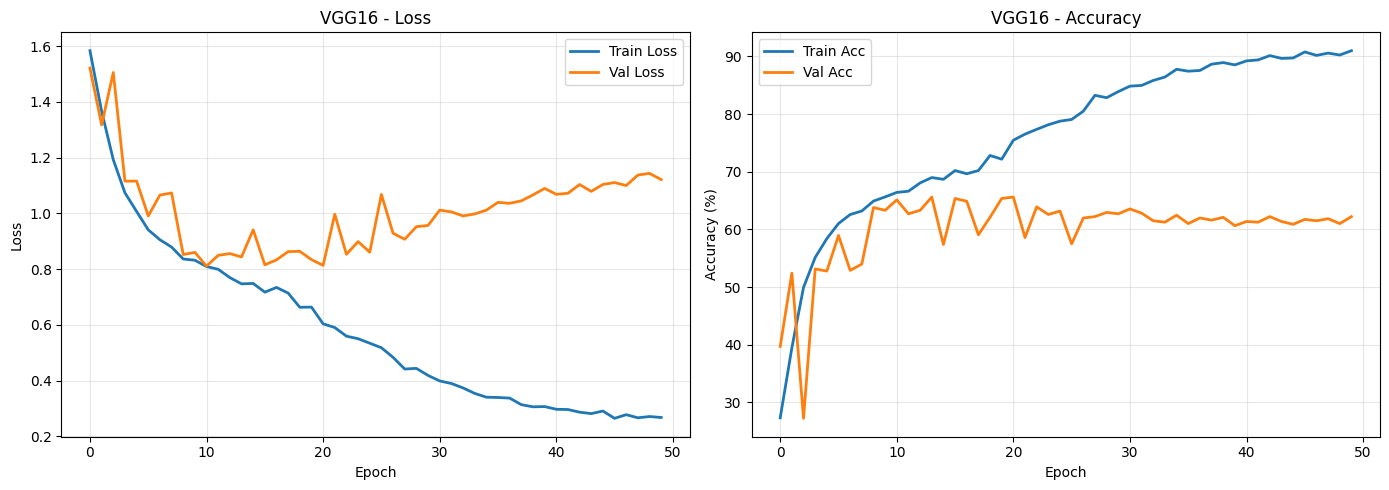

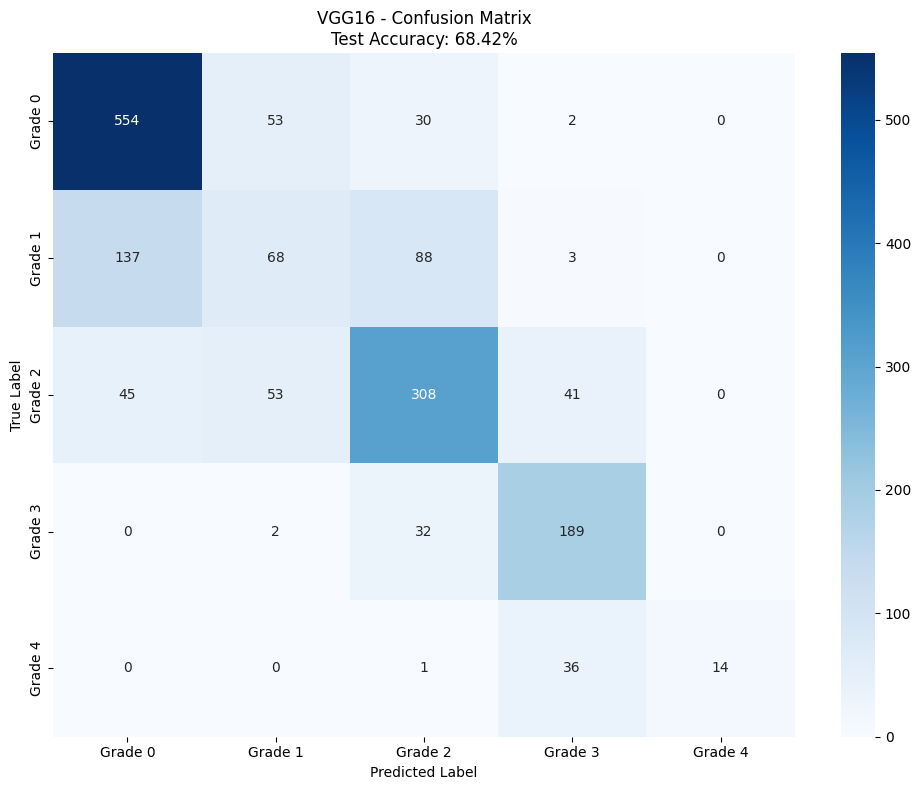


VGG16 completed in 42.06 minutes
Test Accuracy: 68.42%


{'Model': 'VGG16',
 'Parameters': 139116869,
 'Best Val Acc': 65.61743341404359,
 'Test Acc': 68.41787439613528,
 'Training Time (min)': 42.058022260665894}

In [15]:
train_single_model('VGG16', create_vgg16, train_loader, val_loader, test_loader)

## 10. Train VGG19


MODEL: VGG19


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 148MB/s]  


Total parameters: 144,426,565
Trainable parameters: 144,426,565

Epoch [1/50]


...

Train Loss: 0.2677 | Train Acc: 90.83%
Val Loss: 1.1435 | Val Acc: 62.47%

Epoch [50/50]


Validating VGG19: 100%|██████████| 26/26 [00:02<00:00,  8.79it/s]


Train Loss: 0.2509 | Train Acc: 91.19%
Val Loss: 1.1371 | Val Acc: 63.08%

Testing VGG19...


Testing: 100%|██████████| 52/52 [00:05<00:00,  9.24it/s]



VGG19 Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.76      0.85      0.80       639
     Grade 1       0.39      0.35      0.37       296
     Grade 2       0.70      0.65      0.67       447
     Grade 3       0.79      0.79      0.79       223
     Grade 4       0.92      0.69      0.79        51

    accuracy                           0.69      1656
   macro avg       0.71      0.67      0.69      1656
weighted avg       0.69      0.69      0.69      1656



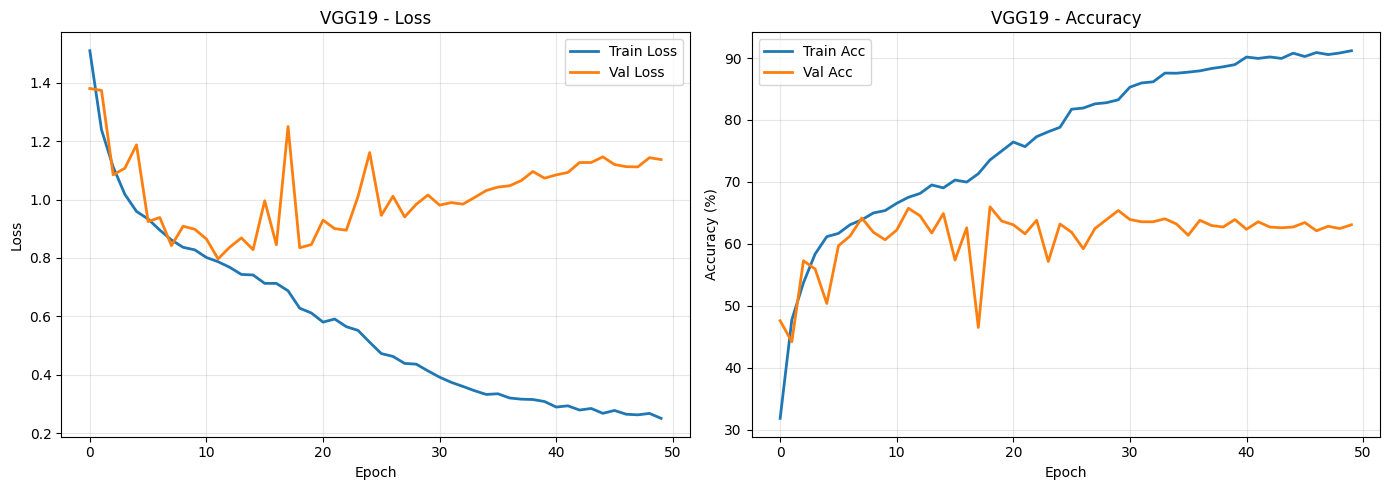

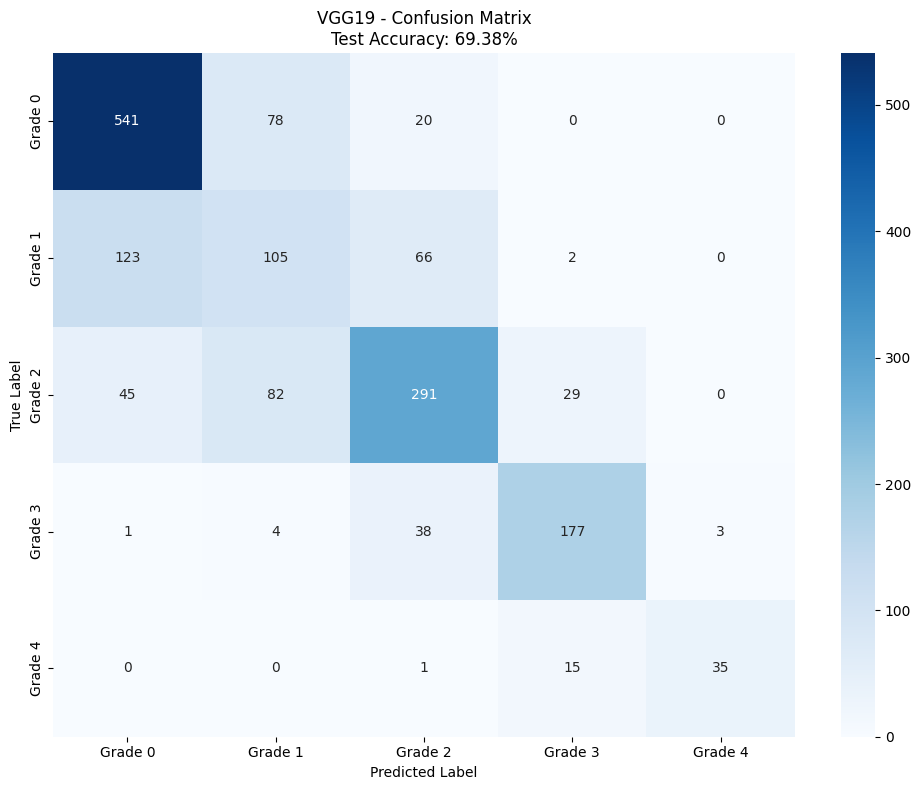


VGG19 completed in 48.39 minutes
Test Accuracy: 69.38%


{'Model': 'VGG19',
 'Parameters': 144426565,
 'Best Val Acc': 65.98062953995158,
 'Test Acc': 69.38405797101449,
 'Training Time (min)': 48.386087779204054}

In [16]:
train_single_model('VGG19', create_vgg19, train_loader, val_loader, test_loader)

## 11. Train ResNet101


MODEL: ResNet101


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:00<00:00, 236MB/s] 


Total parameters: 45,259,333
Trainable parameters: 45,259,333

Epoch [1/50]


...

Train Loss: 0.0398 | Train Acc: 99.13%
Val Loss: 1.4429 | Val Acc: 63.20%

Epoch [50/50]


Validating ResNet101: 100%|██████████| 26/26 [00:02<00:00,  9.79it/s]


Train Loss: 0.0398 | Train Acc: 99.08%
Val Loss: 1.4499 | Val Acc: 62.83%

Testing ResNet101...


Testing: 100%|██████████| 52/52 [00:05<00:00, 10.35it/s]



ResNet101 Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.71      0.87      0.78       639
     Grade 1       0.34      0.24      0.28       296
     Grade 2       0.67      0.63      0.65       447
     Grade 3       0.89      0.72      0.80       223
     Grade 4       0.72      0.92      0.81        51

    accuracy                           0.68      1656
   macro avg       0.67      0.68      0.67      1656
weighted avg       0.66      0.68      0.66      1656



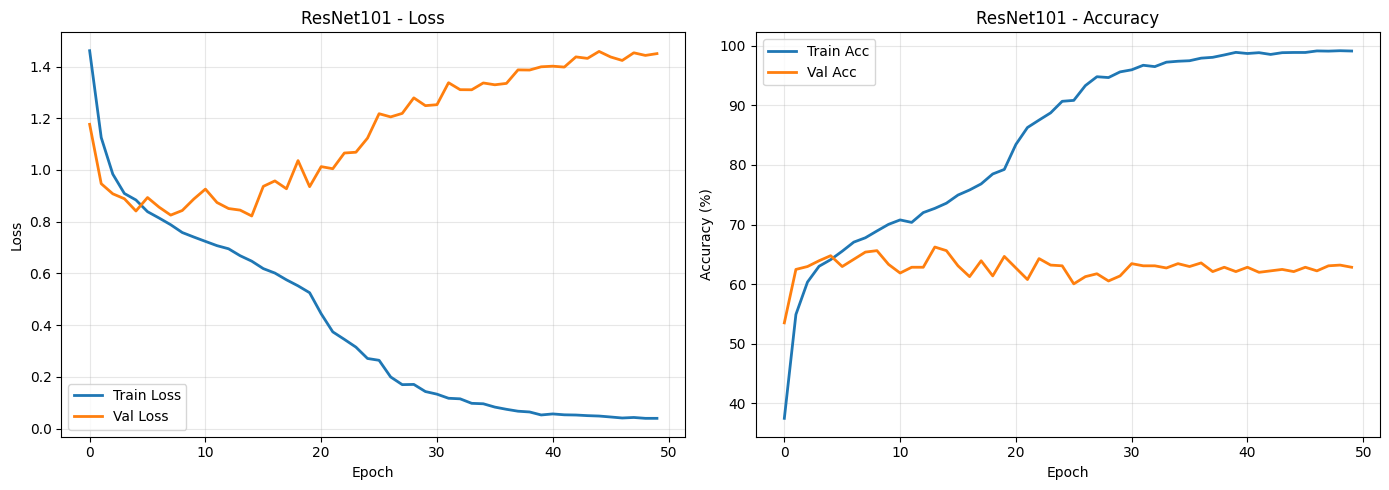

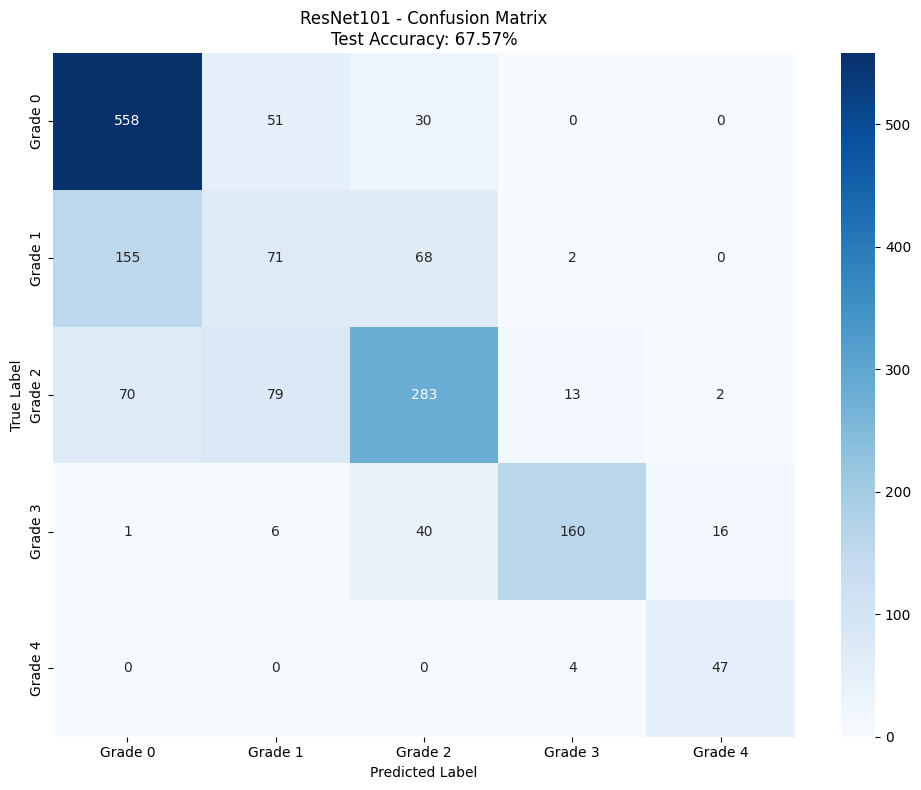


ResNet101 completed in 45.46 minutes
Test Accuracy: 67.57%


{'Model': 'ResNet101',
 'Parameters': 45259333,
 'Best Val Acc': 66.2227602905569,
 'Test Acc': 67.57246376811594,
 'Training Time (min)': 45.45731921195984}

In [17]:
train_single_model('ResNet101', create_resnet101, train_loader, val_loader, test_loader)

## 12. Train MobileNetV2


MODEL: MobileNetV2
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 13.6M/13.6M [00:00<00:00, 211MB/s]


Total parameters: 4,196,613
Trainable parameters: 4,196,613

Epoch [1/50]


Validating MobileNetV2: 100%|██████████| 26/26 [00:01<00:00, 18.73it/s]


Train Loss: 1.4972 | Train Acc: 34.56%
Val Loss: 1.2945 | Val Acc: 47.94%
✓ Best model saved! Val Acc: 47.94%

Epoch [2/50]


...

Train Loss: 0.3022 | Train Acc: 88.87%
Val Loss: 1.0785 | Val Acc: 62.47%

Epoch [50/50]


Validating MobileNetV2: 100%|██████████| 26/26 [00:01<00:00, 19.19it/s]


Train Loss: 0.2760 | Train Acc: 90.43%
Val Loss: 1.1056 | Val Acc: 62.95%

Testing MobileNetV2...


Testing: 100%|██████████| 52/52 [00:02<00:00, 19.30it/s]



MobileNetV2 Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.73      0.83      0.78       639
     Grade 1       0.33      0.22      0.26       296
     Grade 2       0.65      0.69      0.67       447
     Grade 3       0.80      0.78      0.79       223
     Grade 4       0.84      0.75      0.79        51

    accuracy                           0.67      1656
   macro avg       0.67      0.65      0.66      1656
weighted avg       0.65      0.67      0.66      1656



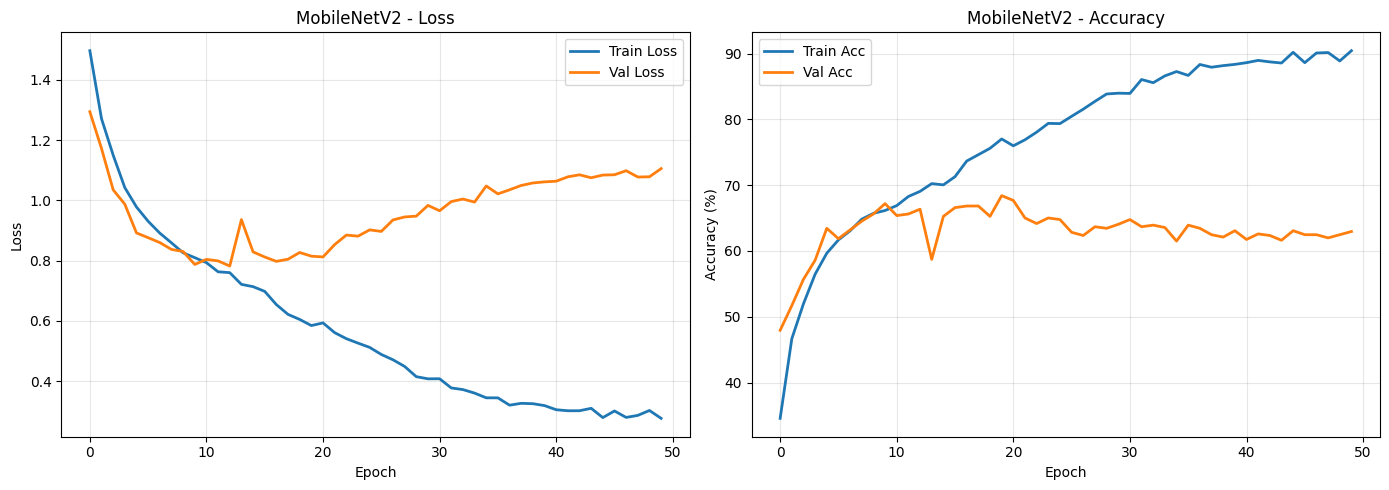

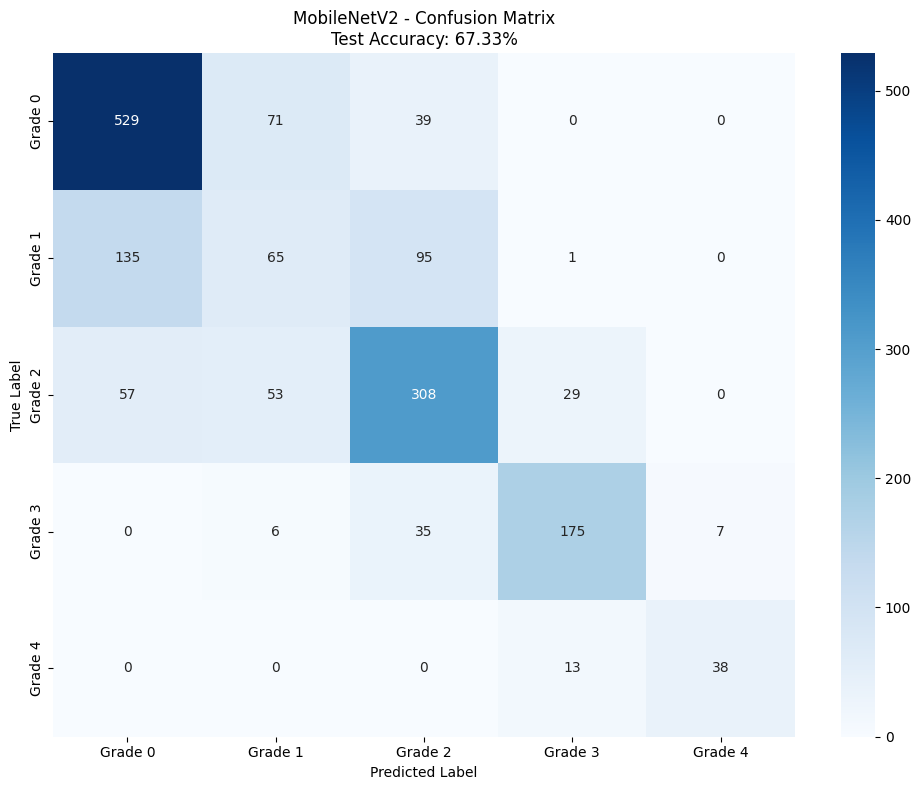


MobileNetV2 completed in 15.73 minutes
Test Accuracy: 67.33%


{'Model': 'MobileNetV2',
 'Parameters': 4196613,
 'Best Val Acc': 68.40193704600485,
 'Test Acc': 67.33091787439614,
 'Training Time (min)': 15.728318162759145}

In [18]:
train_single_model('MobileNetV2', create_mobilenetv2, train_loader, val_loader, test_loader)

## 13. Train InceptionV3 (Requires 299x299 input)

In [19]:
def create_inception_resnet_v2(num_classes=5, pretrained=True):
    if pretrained:
        model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)

        model.aux_logits = False
        model.AuxLogits = None
    else:
        model = models.inception_v3(aux_logits=False)

    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return model

Creating 299x299 data loaders for InceptionV3...

MODEL: InceptionV3
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 185MB/s] 


Total parameters: 22,837,221
Trainable parameters: 22,837,221

Epoch [1/50]


Validating InceptionV3: 100%|██████████| 26/26 [00:02<00:00,  9.44it/s]


Train Loss: 1.2183 | Train Acc: 48.10%
Val Loss: 1.0552 | Val Acc: 55.69%
✓ Best model saved! Val Acc: 55.69%

Epoch [2/50]


...

Train Loss: 0.0107 | Train Acc: 99.65%
Val Loss: 2.0335 | Val Acc: 66.59%

Epoch [50/50]


Validating InceptionV3: 100%|██████████| 26/26 [00:02<00:00,  9.50it/s]


Train Loss: 0.0133 | Train Acc: 99.65%
Val Loss: 2.0345 | Val Acc: 66.95%

Testing InceptionV3...


Testing: 100%|██████████| 52/52 [00:05<00:00, 10.33it/s]



InceptionV3 Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.71      0.83      0.77       639
     Grade 1       0.32      0.24      0.27       296
     Grade 2       0.67      0.63      0.65       447
     Grade 3       0.83      0.80      0.82       223
     Grade 4       0.84      0.80      0.82        51

    accuracy                           0.67      1656
   macro avg       0.67      0.66      0.67      1656
weighted avg       0.65      0.67      0.66      1656



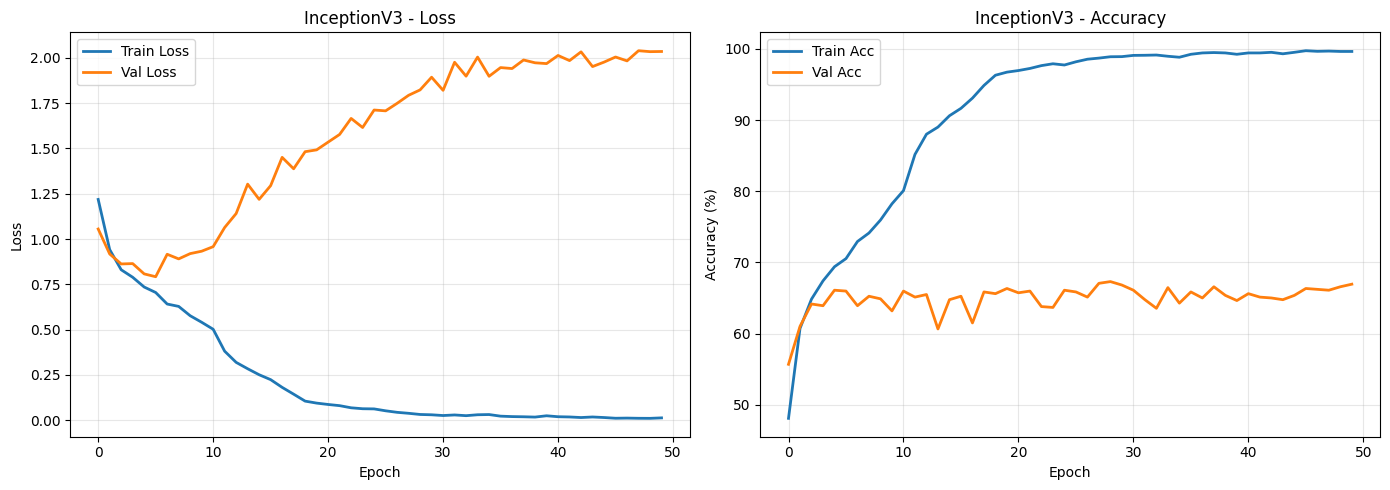

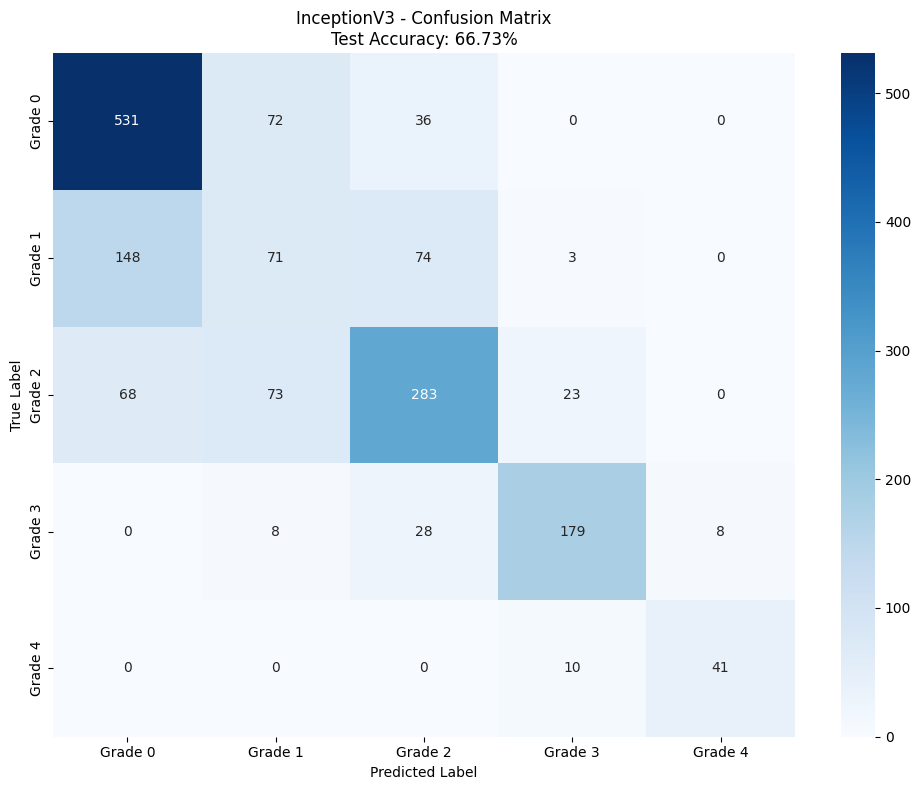


InceptionV3 completed in 47.02 minutes
Test Accuracy: 66.73%


{'Model': 'InceptionV3',
 'Parameters': 22837221,
 'Best Val Acc': 67.31234866828088,
 'Test Acc': 66.72705314009661,
 'Training Time (min)': 47.019892597198485}

In [20]:
print("Creating 299x299 data loaders for InceptionV3...")
train_dataset_inception = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms_inception)
val_dataset_inception = datasets.ImageFolder(root=VAL_DIR, transform=val_test_transforms_inception)
test_dataset_inception = datasets.ImageFolder(root=TEST_DIR, transform=val_test_transforms_inception)

train_loader_inception = DataLoader(train_dataset_inception, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader_inception = DataLoader(val_dataset_inception, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader_inception = DataLoader(test_dataset_inception, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)


train_single_model('InceptionV3', create_inception_resnet_v2, train_loader_inception, val_loader_inception, test_loader_inception)

## 14. Train DenseNet121


MODEL: DenseNet121


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 217MB/s]


Total parameters: 8,664,453
Trainable parameters: 8,664,453

Epoch [1/50]


...

Train Loss: 0.0842 | Train Acc: 97.65%
Val Loss: 1.3869 | Val Acc: 63.56%

Epoch [50/50]


Validating DenseNet121: 100%|██████████| 26/26 [00:02<00:00, 12.86it/s]


Train Loss: 0.0694 | Train Acc: 98.32%
Val Loss: 1.3573 | Val Acc: 63.92%

Testing DenseNet121...


Testing: 100%|██████████| 52/52 [00:03<00:00, 13.84it/s]



DenseNet121 Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.79      0.78      0.78       639
     Grade 1       0.35      0.33      0.34       296
     Grade 2       0.67      0.71      0.69       447
     Grade 3       0.83      0.82      0.82       223
     Grade 4       0.79      0.88      0.83        51

    accuracy                           0.69      1656
   macro avg       0.69      0.70      0.69      1656
weighted avg       0.69      0.69      0.69      1656



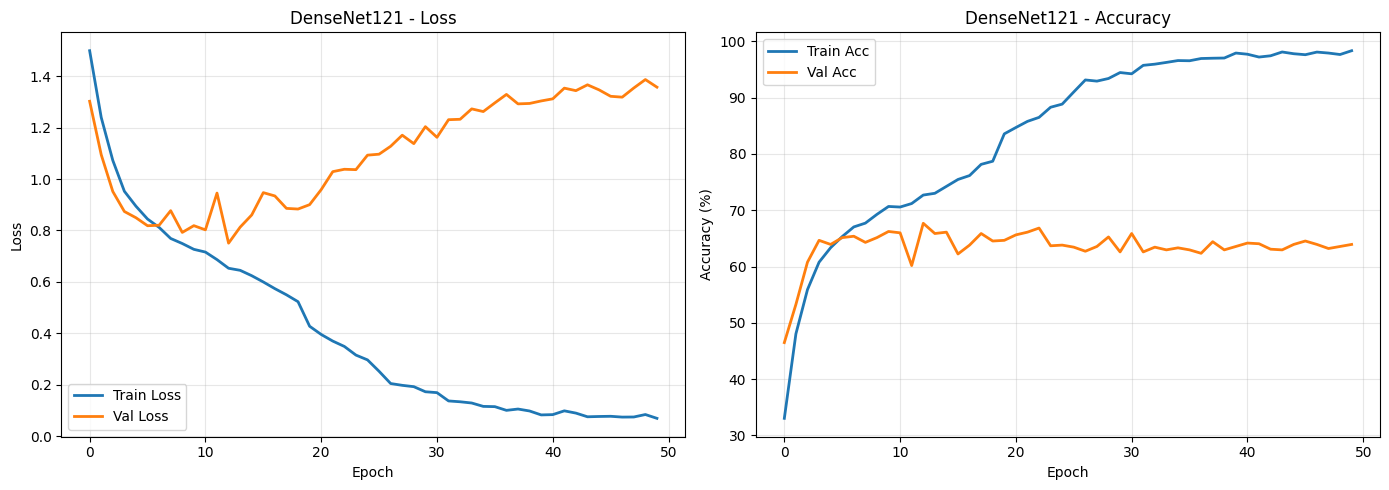

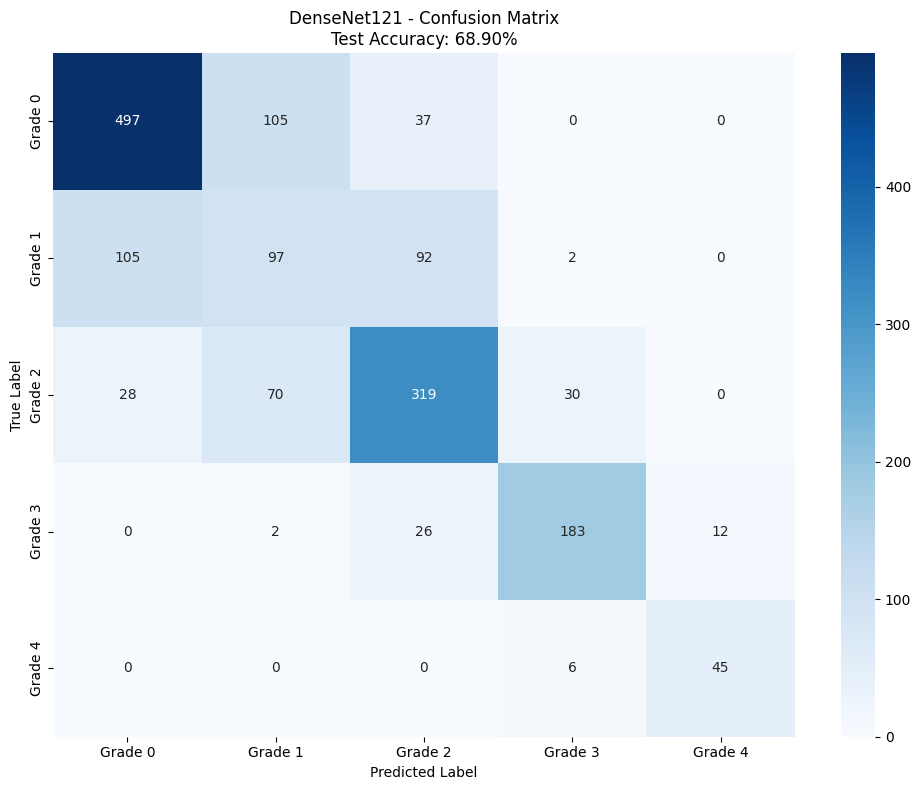


DenseNet121 completed in 30.71 minutes
Test Accuracy: 68.90%


{'Model': 'DenseNet121',
 'Parameters': 8664453,
 'Best Val Acc': 67.67554479418887,
 'Test Acc': 68.90096618357488,
 'Training Time (min)': 30.713576141993205}

In [21]:
train_single_model('DenseNet121', create_densenet121, train_loader, val_loader, test_loader)

## 14.5 Multi-Head Attention Fusion Model
### Automatically fuse the TOP 3 best-performing backbones using Multi-Head Self-Attention
After training all 6 models individually, the top 3 by test accuracy are selected. Each backbone acts as one "token" — the attention mechanism learns which models to trust for each input.

In [22]:
import torch
import torch.nn as nn
from torchvision import models


class VGG16Features(nn.Module):
    def __init__(self, pretrained_path=None):
        super().__init__()
        base = models.vgg16(pretrained=False)

        base.classifier = base.classifier[:-1]
        self.model = base
        self.out_dim = 4096
        if pretrained_path:
            self._load_weights(pretrained_path)

    def _load_weights(self, path):
        state = torch.load(path, map_location='cpu')

        model_state = self.model.state_dict()
        filtered = {k: v for k, v in state.items() if k in model_state and v.shape == model_state[k].shape}
        model_state.update(filtered)
        self.model.load_state_dict(model_state)
        print(f"  VGG16: loaded {len(filtered)}/{len(model_state)} layers from checkpoint")

    def forward(self, x):
        return self.model(x)


class VGG19Features(nn.Module):
    def __init__(self, pretrained_path=None):
        super().__init__()
        base = models.vgg19(pretrained=False)
        base.classifier = base.classifier[:-1]
        self.model = base
        self.out_dim = 4096
        if pretrained_path:
            self._load_weights(pretrained_path)

    def _load_weights(self, path):
        state = torch.load(path, map_location='cpu')
        model_state = self.model.state_dict()
        filtered = {k: v for k, v in state.items() if k in model_state and v.shape == model_state[k].shape}
        model_state.update(filtered)
        self.model.load_state_dict(model_state)
        print(f"  VGG19: loaded {len(filtered)}/{len(model_state)} layers from checkpoint")

    def forward(self, x):
        return self.model(x)


class ResNet101Features(nn.Module):
    def __init__(self, pretrained_path=None):
        super().__init__()
        base = models.resnet101(pretrained=False)
        self.out_dim = base.fc.in_features
        base.fc = nn.Identity()
        self.model = base
        if pretrained_path:
            self._load_weights(pretrained_path)

    def _load_weights(self, path):
        state = torch.load(path, map_location='cpu')
        model_state = self.model.state_dict()
        filtered = {k: v for k, v in state.items() if k in model_state and v.shape == model_state[k].shape}
        model_state.update(filtered)
        self.model.load_state_dict(model_state)
        print(f"  ResNet101: loaded {len(filtered)}/{len(model_state)} layers from checkpoint")

    def forward(self, x):
        return self.model(x)


class MobileNetV2Features(nn.Module):
    def __init__(self, pretrained_path=None):
        super().__init__()
        base = models.mobilenet_v2(pretrained=False)
        self.out_dim = base.classifier[1].in_features
        base.classifier = nn.Identity()
        self.model = base
        if pretrained_path:
            self._load_weights(pretrained_path)

    def _load_weights(self, path):
        state = torch.load(path, map_location='cpu')
        model_state = self.model.state_dict()
        filtered = {k: v for k, v in state.items() if k in model_state and v.shape == model_state[k].shape}
        model_state.update(filtered)
        self.model.load_state_dict(model_state)
        print(f"  MobileNetV2: loaded {len(filtered)}/{len(model_state)} layers from checkpoint")

    def forward(self, x):
        return self.model(x)


class InceptionV3Features(nn.Module):
    def __init__(self, pretrained_path=None):
        super().__init__()
        base = models.inception_v3(aux_logits=False)
        self.out_dim = base.fc.in_features
        base.fc = nn.Identity()
        self.model = base
        if pretrained_path:
            self._load_weights(pretrained_path)

    def _load_weights(self, path):
        state = torch.load(path, map_location='cpu')
        model_state = self.model.state_dict()
        filtered = {k: v for k, v in state.items() if k in model_state and v.shape == model_state[k].shape}
        model_state.update(filtered)
        self.model.load_state_dict(model_state)
        print(f"  InceptionV3: loaded {len(filtered)}/{len(model_state)} layers from checkpoint")

    def forward(self, x):
        return self.model(x)


class DenseNet121Features(nn.Module):
    def __init__(self, pretrained_path=None):
        super().__init__()
        base = models.densenet121(pretrained=False)
        self.out_dim = base.classifier.in_features
        base.classifier = nn.Identity()
        self.model = base
        if pretrained_path:
            self._load_weights(pretrained_path)

    def _load_weights(self, path):
        state = torch.load(path, map_location='cpu')
        model_state = self.model.state_dict()
        filtered = {k: v for k, v in state.items() if k in model_state and v.shape == model_state[k].shape}
        model_state.update(filtered)
        self.model.load_state_dict(model_state)
        print(f"  DenseNet121: loaded {len(filtered)}/{len(model_state)} layers from checkpoint")

    def forward(self, x):
        return self.model(x)


class MultiModelAttentionFusion(nn.Module):
    def __init__(self, backbone_list, embed_dim=512, num_heads=8, num_classes=5,
                 dropout=0.3, freeze_backbones=True):
        super().__init__()

        self.num_models = len(backbone_list)
        self.embed_dim = embed_dim


        self.backbones = nn.ModuleList(backbone_list)


        if freeze_backbones:
            for backbone in self.backbones:
                for param in backbone.parameters():
                    param.requires_grad = False


        self.projectors = nn.ModuleList([
            nn.Sequential(
                nn.Linear(bb.out_dim, embed_dim),
                nn.LayerNorm(embed_dim),
                nn.GELU(),
            )
            for bb in backbone_list
        ])


        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)


        self.pos_embedding = nn.Parameter(
            torch.randn(1, self.num_models + 1, embed_dim) * 0.02
        )


        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)


        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )


        self.last_attention_weights = None

        print(f"\n{'='*60}")
        print("MultiModelAttentionFusion initialized:")
        print(f"  Backbones: {self.num_models}")
        print(f"  Embed dim: {embed_dim}")
        print(f"  Attention heads: {num_heads}")
        print(f"  Transformer layers: 2")
        print(f"  Backbones frozen: {freeze_backbones}")
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  Total parameters: {total_params:,}")
        print(f"  Trainable parameters: {trainable_params:,}")
        print(f"{'='*60}")

    def forward(self, x_224, x_299=None):
        B = x_224.size(0)


        if x_299 is None:
            x_299 = nn.functional.interpolate(x_224, size=(299, 299), mode='bilinear', align_corners=False)


        model_features = []
        for i, (backbone, projector) in enumerate(zip(self.backbones, self.projectors)):
            if isinstance(backbone, InceptionV3Features):
                with torch.no_grad() if not backbone.model.training else torch.enable_grad():
                    feat = backbone(x_299)
            else:
                with torch.no_grad() if not backbone.model.training else torch.enable_grad():
                    feat = backbone(x_224)

            projected = projector(feat)
            model_features.append(projected)


        tokens = torch.stack(model_features, dim=1)


        cls_tokens = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls_tokens, tokens], dim=1)


        tokens = tokens + self.pos_embedding


        attended = self.transformer(tokens)


        cls_output = attended[:, 0]


        logits = self.classifier(cls_output)

        return logits


print("✓ MultiModelAttentionFusion class defined")
print("  Architecture: Top-3 backbones → project → [CLS] + tokens → Transformer → classify")

✓ MultiModelAttentionFusion class defined
  Architecture: Top-3 backbones → project → [CLS] + tokens → Transformer → classify


## 14.6 Build & Train the Attention Fusion Model
Automatically picks the **top 3 models** by test accuracy from `results_summary`, loads their pretrained weights, freezes them, and trains only the attention + classifier layers.

In [23]:
print("Selecting the TOP 3 models by test accuracy for fusion...\n")


top3_df = pd.DataFrame(results_summary).sort_values('Test Acc', ascending=False).head(3)
top3_names = top3_df['Model'].tolist()

print(f"Top 3 models selected:")
for i, row in top3_df.iterrows():
    print(f"  {row['Model']} — Test Acc: {row['Test Acc']:.2f}%")


FEATURE_EXTRACTOR_MAP = {
    'VGG16':       (VGG16Features,       'best_vgg16.pth'),
    'VGG19':       (VGG19Features,       'best_vgg19.pth'),
    'ResNet101':   (ResNet101Features,   'best_resnet101.pth'),
    'MobileNetV2': (MobileNetV2Features, 'best_mobilenetv2.pth'),
    'InceptionV3': (InceptionV3Features, 'best_inceptionv3.pth'),
    'DenseNet121': (DenseNet121Features, 'best_densenet121.pth'),
}


print("\nInitializing backbone feature extractors:")
backbone_list = []
for name in top3_names:
    ExtractorClass, weight_file = FEATURE_EXTRACTOR_MAP[name]
    path = weight_file if os.path.exists(weight_file) else None
    if path is None:
        print(f"  ⚠️ {name}: weight file not found, using random init")
    backbone_list.append(ExtractorClass(pretrained_path=path))


fusion_model = MultiModelAttentionFusion(
    backbone_list=backbone_list,
    embed_dim=512,
    num_heads=8,
    num_classes=NUM_CLASSES,
    dropout=0.3,
    freeze_backbones=True
)
fusion_model = fusion_model.to(device)


print("\n" + "="*70)
print(f"TRAINING MULTI-HEAD ATTENTION FUSION MODEL (Top 3: {', '.join(top3_names)})")
print("="*70)


fusion_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, fusion_model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)
fusion_criterion = nn.CrossEntropyLoss()
fusion_scheduler = optim.lr_scheduler.CosineAnnealingLR(fusion_optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)


FUSION_EPOCHS = NUM_EPOCHS
best_fusion_val_acc = 0.0
fusion_train_history = {'loss': [], 'acc': []}
fusion_val_history = {'loss': [], 'acc': []}

fusion_start_time = time.time()

for epoch in range(FUSION_EPOCHS):
    fusion_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f'Fusion Train Epoch {epoch+1}/{FUSION_EPOCHS}')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        fusion_optimizer.zero_grad()
        outputs = fusion_model(inputs)
        loss = fusion_criterion(outputs, labels)
        loss.backward()
        fusion_optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.2f}%'})

    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total
    fusion_train_history['loss'].append(train_loss)
    fusion_train_history['acc'].append(train_acc)


    fusion_model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f'Fusion Val Epoch {epoch+1}'):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = fusion_model(inputs)
            loss = fusion_criterion(outputs, labels)
            val_loss_sum += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss = val_loss_sum / len(val_loader)
    val_acc = 100. * val_correct / val_total
    fusion_val_history['loss'].append(val_loss)
    fusion_val_history['acc'].append(val_acc)

    fusion_scheduler.step()

    print(f'Epoch [{epoch+1}/{FUSION_EPOCHS}] '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')


    if val_acc > best_fusion_val_acc:
        best_fusion_val_acc = val_acc
        torch.save(fusion_model.state_dict(), 'best_fusion_multihead_attention.pth')
        print(f'  ✓ Best fusion model saved! Val Acc: {best_fusion_val_acc:.2f}%')

fusion_training_time = time.time() - fusion_start_time

print(f"\nFusion training completed in {fusion_training_time/60:.2f} minutes")
print(f"Best Validation Accuracy: {best_fusion_val_acc:.2f}%")

Selecting the TOP 3 models by test accuracy for fusion...

Top 3 models selected:
  VGG19 — Test Acc: 69.38%
  DenseNet121 — Test Acc: 68.90%
  VGG16 — Test Acc: 68.42%

Initializing backbone feature extractors:


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


  VGG19: loaded 36/36 layers from checkpoint
  DenseNet121: loaded 725/725 layers from checkpoint
  VGG16: loaded 30/30 layers from checkpoint

MultiModelAttentionFusion initialized:
  Backbones: 3
  Embed dim: 512
  Attention heads: 8
  Transformer layers: 2
  Backbones frozen: True
  Total parameters: 291,948,805
  Trainable parameters: 11,164,165


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



TRAINING MULTI-HEAD ATTENTION FUSION MODEL (Top 3: VGG19, DenseNet121, VGG16)


...

Epoch [48/50] Train Loss: 0.4572 | Train Acc: 80.25% | Val Loss: 0.9328 | Val Acc: 67.55%


Fusion Val Epoch 49: 100%|██████████| 26/26 [00:06<00:00,  4.12it/s]


Epoch [49/50] Train Loss: 0.4655 | Train Acc: 80.98% | Val Loss: 0.9327 | Val Acc: 67.31%


Fusion Val Epoch 50: 100%|██████████| 26/26 [00:06<00:00,  4.11it/s]

Epoch [50/50] Train Loss: 0.4620 | Train Acc: 80.53% | Val Loss: 0.9296 | Val Acc: 66.95%

Fusion training completed in 42.17 minutes
Best Validation Accuracy: 70.22%


## 14.7 Evaluate Fusion Model on Test Set

Loading best fusion model weights...


Testing Fusion Model: 100%|██████████| 52/52 [00:12<00:00,  4.22it/s]



MULTI-HEAD ATTENTION FUSION MODEL — TEST RESULTS

Test Accuracy: 70.59%

              precision    recall  f1-score   support

     Grade 0       0.73      0.89      0.80       639
     Grade 1       0.42      0.22      0.28       296
     Grade 2       0.70      0.68      0.69       447
     Grade 3       0.79      0.86      0.82       223
     Grade 4       0.89      0.78      0.83        51

    accuracy                           0.71      1656
   macro avg       0.70      0.69      0.69      1656
weighted avg       0.68      0.71      0.68      1656



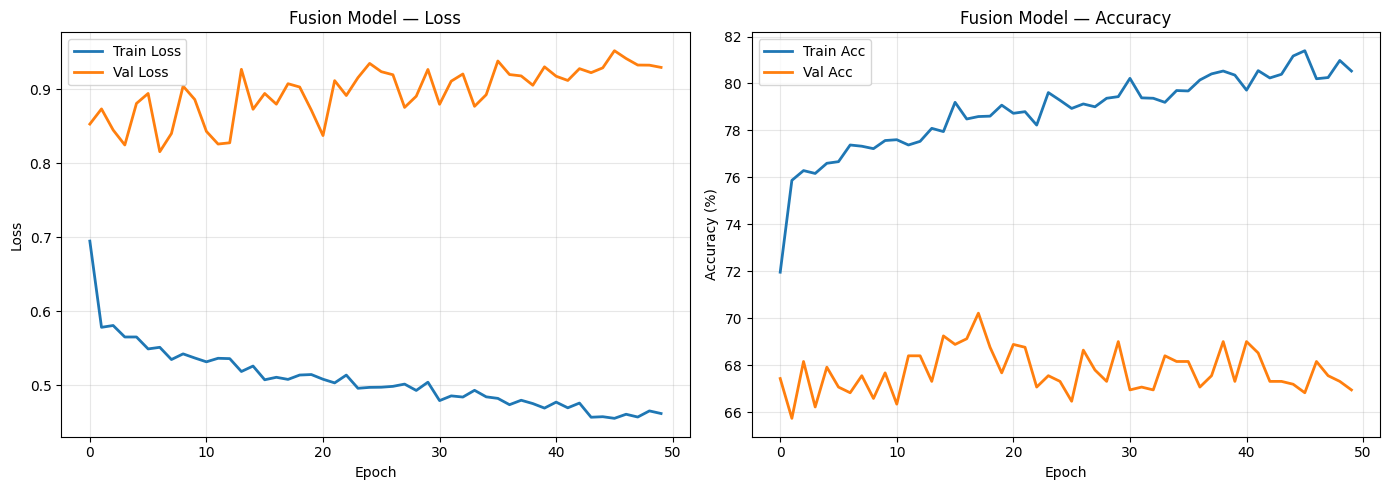

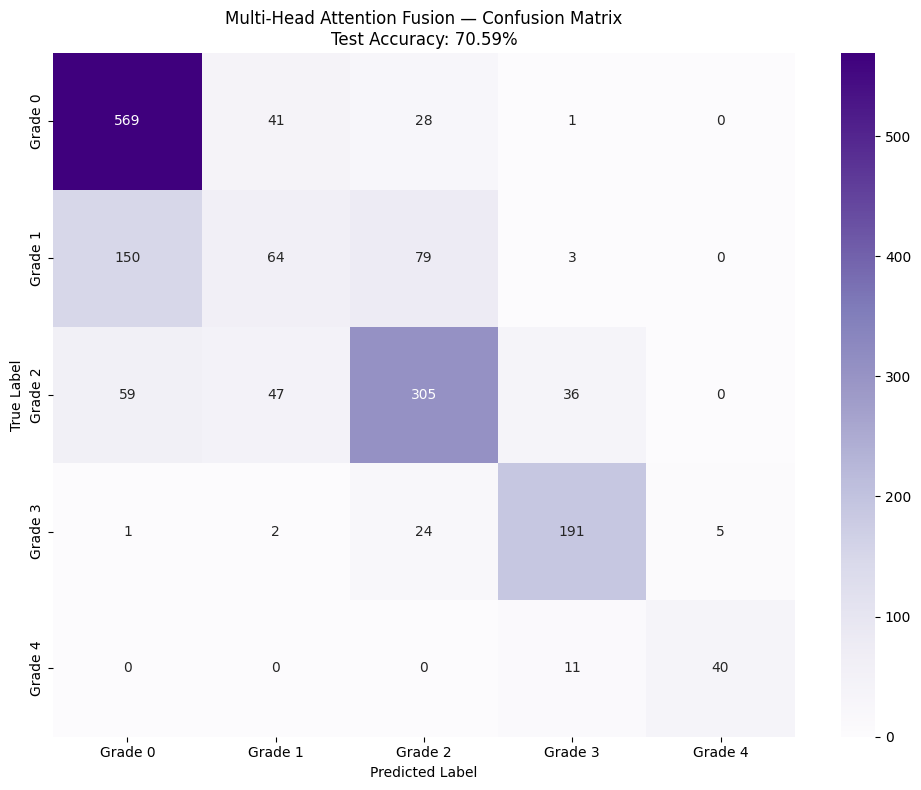


✓ Fusion model test accuracy: 70.59%
✓ Results appended to results_summary for final comparison


In [24]:
print("Loading best fusion model weights...")
fusion_model.load_state_dict(torch.load('best_fusion_multihead_attention.pth'))
fusion_model.eval()


fusion_all_preds = []
fusion_all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc='Testing Fusion Model'):
        inputs = inputs.to(device)
        outputs = fusion_model(inputs)
        _, predicted = outputs.max(1)
        fusion_all_preds.extend(predicted.cpu().numpy())
        fusion_all_labels.extend(labels.numpy())

fusion_test_labels = np.array(fusion_all_labels)
fusion_test_preds = np.array(fusion_all_preds)
fusion_test_acc = accuracy_score(fusion_test_labels, fusion_test_preds) * 100


class_names = ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
print(f'\n{"="*70}')
print(f'MULTI-HEAD ATTENTION FUSION MODEL — TEST RESULTS')
print(f'{"="*70}')
print(f'\nTest Accuracy: {fusion_test_acc:.2f}%\n')
print(classification_report(fusion_test_labels, fusion_test_preds, target_names=class_names))


fusion_total_params = sum(p.numel() for p in fusion_model.parameters())
results_summary.append({
    'Model': 'Fusion (MHA)',
    'Parameters': fusion_total_params,
    'Best Val Acc': best_fusion_val_acc,
    'Test Acc': fusion_test_acc,
    'Training Time (min)': fusion_training_time / 60
})


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fusion_train_history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(fusion_val_history['loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Fusion Model — Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(fusion_train_history['acc'], label='Train Acc', linewidth=2)
axes[1].plot(fusion_val_history['acc'], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Fusion Model — Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fusion_mha_training_history.png', dpi=300)
plt.show()
plt.close()


cm = confusion_matrix(fusion_test_labels, fusion_test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Multi-Head Attention Fusion — Confusion Matrix\nTest Accuracy: {fusion_test_acc:.2f}%')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('fusion_mha_confusion_matrix.png', dpi=300)
plt.show()
plt.close()

print(f'\n✓ Fusion model test accuracy: {fusion_test_acc:.2f}%')
print(f'✓ Results appended to results_summary for final comparison')

## 15. Final Results Comparison

In [25]:
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)

results_df = pd.DataFrame(results_summary)
results_df = results_df.sort_values('Test Acc', ascending=False)
print("\n", results_df.to_string(index=False))


results_df.to_csv('model_comparison_results.csv', index=False)
print("\n✓ Results saved to 'model_comparison_results.csv'")


FINAL RESULTS SUMMARY

        Model  Parameters  Best Val Acc  Test Acc  Training Time (min)
Fusion (MHA)   291948805     70.217918 70.591787            42.172681
       VGG19   144426565     65.980630 69.384058            48.386088
 DenseNet121     8664453     67.675545 68.900966            30.713576
       VGG16   139116869     65.617433 68.417874            42.058022
   ResNet101    45259333     66.222760 67.572464            45.457319
 MobileNetV2     4196613     68.401937 67.330918            15.728318
 InceptionV3    22837221     67.312349 66.727053            47.019893

✓ Results saved to 'model_comparison_results.csv'


## 16. Visualization - Model Comparison

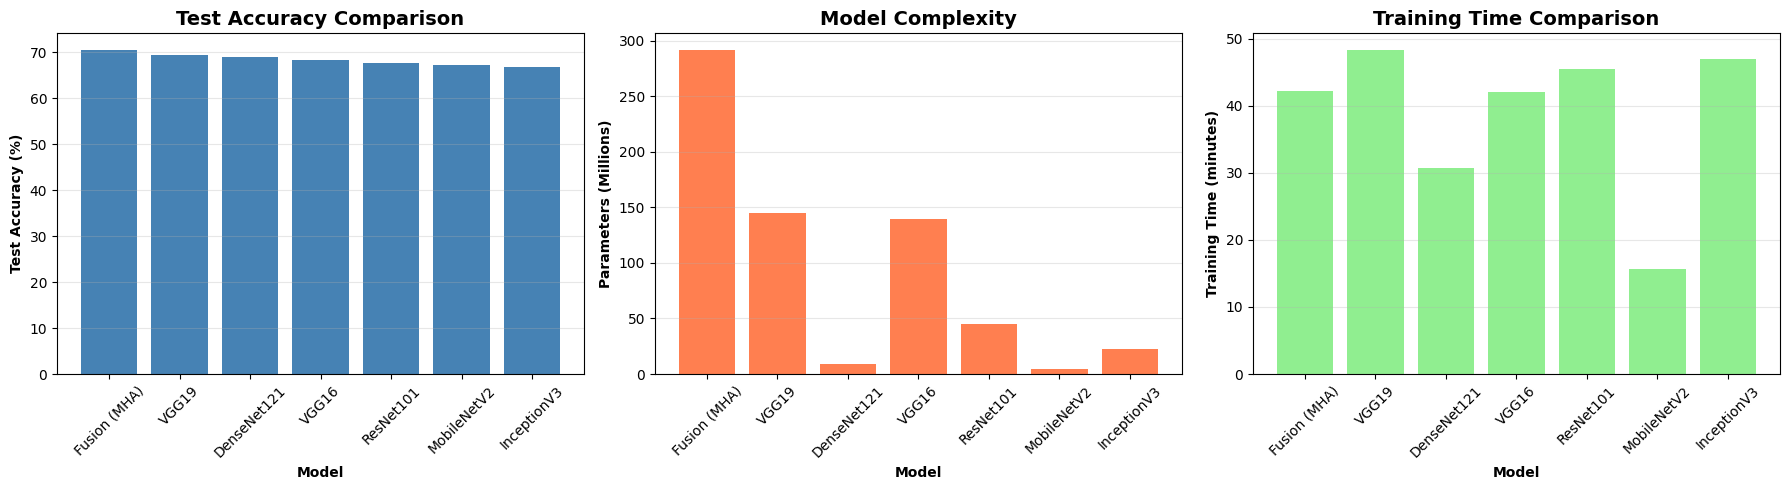


VISUALIZATION COMPLETE!

Best Model: Fusion (MHA) with 70.59% test accuracy

Files saved:
  - Individual model weights: best_*.pth
  - Training curves: *_training_history.png
  - Confusion matrices: *_confusion_matrix.png
  - Comparison results: model_comparison_results.csv
  - Comparison plots: model_comparison.png


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].bar(results_df['Model'], results_df['Test Acc'], color='steelblue')
axes[0].set_xlabel('Model', fontweight='bold')
axes[0].set_ylabel('Test Accuracy (%)', fontweight='bold')
axes[0].set_title('Test Accuracy Comparison', fontweight='bold', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)


axes[1].bar(results_df['Model'], results_df['Parameters']/1e6, color='coral')
axes[1].set_xlabel('Model', fontweight='bold')
axes[1].set_ylabel('Parameters (Millions)', fontweight='bold')
axes[1].set_title('Model Complexity', fontweight='bold', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)


axes[2].bar(results_df['Model'], results_df['Training Time (min)'], color='lightgreen')
axes[2].set_xlabel('Model', fontweight='bold')
axes[2].set_ylabel('Training Time (minutes)', fontweight='bold')
axes[2].set_title('Training Time Comparison', fontweight='bold', fontsize=14)
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("VISUALIZATION COMPLETE!")
print("="*70)
print(f"\nBest Model: {results_df.iloc[0]['Model']} with {results_df.iloc[0]['Test Acc']:.2f}% test accuracy")
print("\nFiles saved:")
print("  - Individual model weights: best_*.pth")
print("  - Training curves: *_training_history.png")
print("  - Confusion matrices: *_confusion_matrix.png")
print("  - Comparison results: model_comparison_results.csv")
print("  - Comparison plots: model_comparison.png")

## 17. List All Generated Files (Kaggle Auto-Saves to /kaggle/working/)

In [27]:
print("All results are saved in /kaggle/working/")
print("\nGenerated files:")
print("  Model weights:")
for model_name in ['vgg16', 'vgg19', 'resnet101', 'mobilenetv2', 'inceptionv3', 'densenet121']:
    if os.path.exists(f'best_{model_name}.pth'):
        print(f"    ✓ best_{model_name}.pth")
if os.path.exists('best_fusion_multihead_attention.pth'):
    print(f"    ✓ best_fusion_multihead_attention.pth")

print("\n  Training history plots:")
for model_name in ['vgg16', 'vgg19', 'resnet101', 'mobilenetv2', 'inceptionv3', 'densenet121']:
    if os.path.exists(f'{model_name}_training_history.png'):
        print(f"    ✓ {model_name}_training_history.png")
if os.path.exists('fusion_mha_training_history.png'):
    print(f"    ✓ fusion_mha_training_history.png")

print("\n  Confusion matrices:")
for model_name in ['vgg16', 'vgg19', 'resnet101', 'mobilenetv2', 'inceptionv3', 'densenet121']:
    if os.path.exists(f'{model_name}_confusion_matrix.png'):
        print(f"    ✓ {model_name}_confusion_matrix.png")
if os.path.exists('fusion_mha_confusion_matrix.png'):
    print(f"    ✓ fusion_mha_confusion_matrix.png")

print("\n  Comparison files:")
if os.path.exists('model_comparison_results.csv'):
    print("    ✓ model_comparison_results.csv")
if os.path.exists('model_comparison.png'):
    print("    ✓ model_comparison.png")

print("\n💡 Tip: You can download all outputs from the 'Output' tab on the right side of Kaggle!")

All results are saved in /kaggle/working/

Generated files:
  Model weights:
    ✓ best_vgg16.pth
    ✓ best_vgg19.pth
    ✓ best_resnet101.pth
    ✓ best_mobilenetv2.pth
    ✓ best_inceptionv3.pth
    ✓ best_densenet121.pth
    ✓ best_fusion_multihead_attention.pth

  Training history plots:
    ✓ vgg16_training_history.png
    ✓ vgg19_training_history.png
    ✓ resnet101_training_history.png
    ✓ mobilenetv2_training_history.png
    ✓ inceptionv3_training_history.png
    ✓ densenet121_training_history.png
    ✓ fusion_mha_training_history.png

  Confusion matrices:
    ✓ vgg16_confusion_matrix.png
    ✓ vgg19_confusion_matrix.png
    ✓ resnet101_confusion_matrix.png
    ✓ mobilenetv2_confusion_matrix.png
    ✓ inceptionv3_confusion_matrix.png
    ✓ densenet121_confusion_matrix.png
    ✓ fusion_mha_confusion_matrix.png

  Comparison files:
    ✓ model_comparison_results.csv
    ✓ model_comparison.png

💡 Tip: You can download all outputs from the 'Output' tab on the right side of Kagg

In [28]:
import os

file_to_delete = '/kaggle/working/selected_files.zip'

if os.path.exists(file_to_delete):
    os.remove(file_to_delete)
    print(f"✅ Deleted: {file_to_delete}")
else:
    print(f"⚠️ File not found: {file_to_delete}")

⚠️ File not found: /kaggle/working/selected_files.zip


In [ ]:
import os
import zipfile


source_dir = '/kaggle/working/'
output_zip = '/kaggle/working/selected_files.zip'


allowed_ext = {'.pth', '.png', '.csv', '.db'}


with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(source_dir):
        dirs[:] = [d for d in dirs if d != '.ipynb_checkpoints']
        for file in files:
            ext = os.path.splitext(file)[1].lower()
            if ext in allowed_ext:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, source_dir)
                zipf.write(file_path, arcname)
                print(f"📦 Added: {arcname}")

print("\n✅ Done! Created 'selected_files.zip' with .pth, .png, .csv, and .db files only.")

📦 Added: mobilenetv2_training_history.png
📦 Added: best_inceptionv3.pth


In [ ]:
import os

print("Files in /kaggle/working/:")
for f in os.listdir('/kaggle/working/'):
    print(f)

In [ ]:
from IPython.display import FileLink, display

display(FileLink('/kaggle/working/selected_files.zip'))